<a href="https://colab.research.google.com/github/SrishanthGorla/SERAI/blob/main/SERI3_1_FGSM_Attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install adversarial-robustness-toolbox

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Training images: 50000
Testing images: 10000


In [ ]:
from torch.utils.data import DataLoader, Subset

train_subset = Subset(train_dataset, range(10000))
test_subset = Subset(test_dataset, range(2000))

train_loader = DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_subset))
print("Testing samples:", len(test_subset))

Training samples: 10000
Testing samples: 2000


In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {running_loss / len(train_loader):.4f}"
    )

Epoch [1/5], Loss: 1.8664
Epoch [2/5], Loss: 1.5233
Epoch [3/5], Loss: 1.3674
Epoch [4/5], Loss: 1.2495
Epoch [5/5], Loss: 1.1440


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

clean_accuracy = 100 * correct / total

print(f"Clean Test Accuracy: {clean_accuracy:.2f}%")

Clean Test Accuracy: 55.20%


In [ ]:
art_classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 32, 32),
    nb_classes=10,
    clip_values=(0.0, 1.0)
)

print("ART classifier created successfully!")

ART classifier created successfully!


In [ ]:
images = []
labels = []

for i in range(20):

    image, label = test_dataset[i]

    images.append(image.numpy())
    labels.append(label)

x_test = np.array(images)
y_test = np.array(labels)

print("Selected images shape:", x_test.shape)
print("Selected labels:", y_test)

Selected images shape: (20, 3, 32, 32)
Selected labels: [3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6]


In [ ]:
original_predictions = art_classifier.predict(x_test)

original_labels = np.argmax(original_predictions, axis=1)

original_confidence = np.max(
    original_predictions,
    axis=1
)

print("Original predictions:")
print(original_labels)

print("\nOriginal confidence:")
print(original_confidence)

Original predictions:
[3 1 8 8 6 6 1 6 3 1 0 9 3 7 9 8 3 3 8 6]

Original confidence:
[2.1536417 5.0117373 3.1096733 3.9157045 3.3931637 3.7955406 3.2030506
 3.4264755 2.3721187 5.565221  1.4178015 5.518165  2.1811042 3.6950548
 5.889381  1.486333  2.3065226 0.9663273 4.5398865 5.380595 ]


In [ ]:
epsilon = 0.01

attack = FastGradientMethod(
    estimator=art_classifier,
    eps=epsilon
)

x_test_adv = attack.generate(
    x=x_test
)

print("Adversarial examples generated!")
print("Adversarial data shape:", x_test_adv.shape)

Adversarial examples generated!
Adversarial data shape: (20, 3, 32, 32)


In [ ]:
adversarial_predictions = art_classifier.predict(
    x_test_adv
)

adversarial_labels = np.argmax(
    adversarial_predictions,
    axis=1
)

adversarial_confidence = np.max(
    adversarial_predictions,
    axis=1
)

print("Adversarial predictions:")
print(adversarial_labels)

print("\nAdversarial confidence:")
print(adversarial_confidence)

Adversarial predictions:
[6 8 0 0 4 6 1 4 4 1 8 9 6 7 9 0 3 9 8 6]

Adversarial confidence:
[1.6072469 4.8695874 3.2901433 3.4471986 3.2995553 2.913772  2.3407683
 3.114882  2.265241  4.84027   1.438699  5.2481065 2.2709544 2.7517676
 5.5646977 1.0307858 1.8130505 1.0448405 3.8091598 4.315428 ]


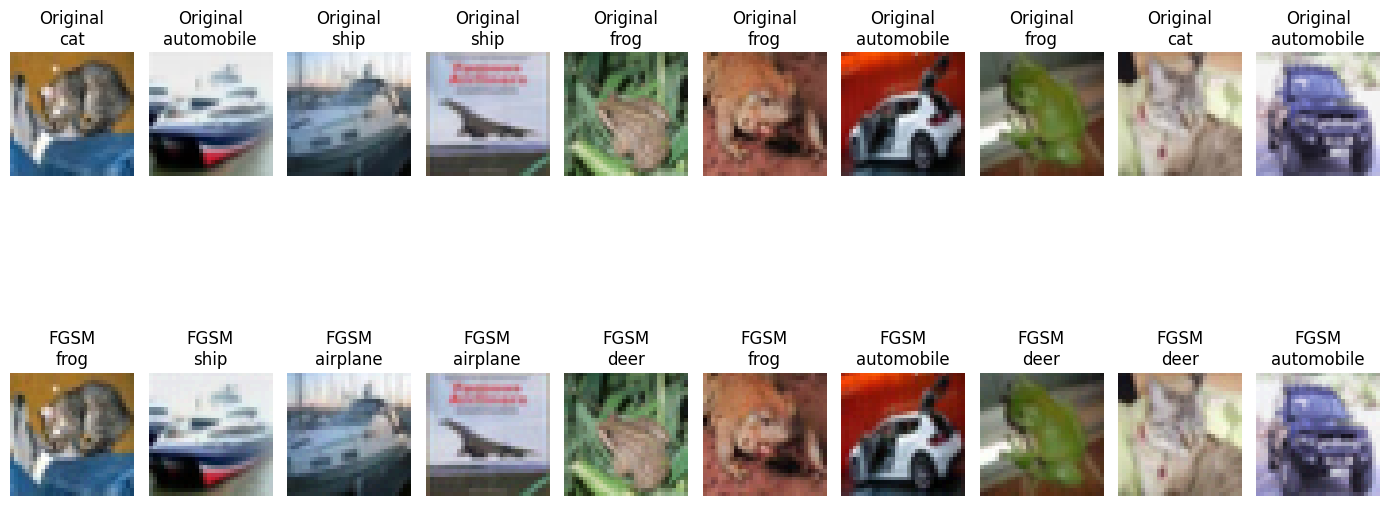

In [ ]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(14, 8))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)

    original_img = np.transpose(
        x_test[i],
        (1, 2, 0)
    )

    plt.imshow(original_img)
    plt.title(
        f"Original\n{class_names[original_labels[i]]}"
    )
    plt.axis("off")

    # Adversarial
    plt.subplot(2, 10, i + 11)

    adv_img = np.transpose(
        x_test_adv[i],
        (1, 2, 0)
    )

    plt.imshow(np.clip(adv_img, 0, 1))

    plt.title(
        f"FGSM\n{class_names[adversarial_labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
clean_correct = np.sum(
    original_labels == y_test
)

adv_correct = np.sum(
    adversarial_labels == y_test
)

clean_accuracy_selected = (
    clean_correct / len(y_test)
) * 100

adv_accuracy_selected = (
    adv_correct / len(y_test)
) * 100

accuracy_drop = (
    clean_accuracy_selected -
    adv_accuracy_selected
)

print(
    f"Clean Accuracy: "
    f"{clean_accuracy_selected:.2f}%"
)

print(
    f"Adversarial Accuracy: "
    f"{adv_accuracy_selected:.2f}%"
)

print(
    f"Accuracy Drop: "
    f"{accuracy_drop:.2f}%"
)

Clean Accuracy: 75.00%
Adversarial Accuracy: 50.00%
Accuracy Drop: 25.00%


In [ ]:
print("Image-wise results:\n")

for i in range(len(y_test)):

    print(
        f"Image {i+1}: "
        f"Actual={class_names[y_test[i]]}, "
        f"Original={class_names[original_labels[i]]}, "
        f"Adversarial={class_names[adversarial_labels[i]]}"
    )

Image-wise results:

Image 1: Actual=cat, Original=cat, Adversarial=frog
Image 2: Actual=ship, Original=automobile, Adversarial=ship
Image 3: Actual=ship, Original=ship, Adversarial=airplane
Image 4: Actual=airplane, Original=ship, Adversarial=airplane
Image 5: Actual=frog, Original=frog, Adversarial=deer
Image 6: Actual=frog, Original=frog, Adversarial=frog
Image 7: Actual=automobile, Original=automobile, Adversarial=automobile
Image 8: Actual=frog, Original=frog, Adversarial=deer
Image 9: Actual=cat, Original=cat, Adversarial=deer
Image 10: Actual=automobile, Original=automobile, Adversarial=automobile
Image 11: Actual=airplane, Original=airplane, Adversarial=ship
Image 12: Actual=truck, Original=truck, Adversarial=truck
Image 13: Actual=dog, Original=cat, Adversarial=frog
Image 14: Actual=horse, Original=horse, Adversarial=horse
Image 15: Actual=truck, Original=truck, Adversarial=truck
Image 16: Actual=ship, Original=ship, Adversarial=airplane
Image 17: Actual=dog, Original=cat, Adv

In [ ]:
print(
    f"{'Image':<8}"
    f"{'Actual':<12}"
    f"{'Original':<15}"
    f"{'Orig Conf.':<12}"
    f"{'Adversarial':<15}"
    f"{'Adv Conf.':<12}"
)

print("-" * 74)

for i in range(len(y_test)):

    print(
        f"{i+1:<8}"
        f"{class_names[y_test[i]]:<12}"
        f"{class_names[original_labels[i]]:<15}"
        f"{original_confidence[i]:<12.3f}"
        f"{class_names[adversarial_labels[i]]:<15}"
        f"{adversarial_confidence[i]:<12.3f}"
    )

Image   Actual      Original       Orig Conf.  Adversarial    Adv Conf.   
--------------------------------------------------------------------------
1       cat         cat            2.154       frog           1.607       
2       ship        automobile     5.012       ship           4.870       
3       ship        ship           3.110       airplane       3.290       
4       airplane    ship           3.916       airplane       3.447       
5       frog        frog           3.393       deer           3.300       
6       frog        frog           3.796       frog           2.914       
7       automobile  automobile     3.203       automobile     2.341       
8       frog        frog           3.426       deer           3.115       
9       cat         cat            2.372       deer           2.265       
10      automobile  automobile     5.565       automobile     4.840       
11      airplane    airplane       1.418       ship           1.439       
12      truck       truck

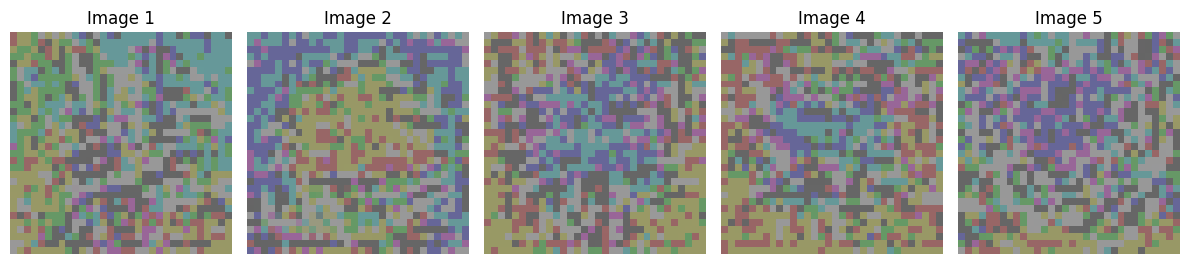

In [ ]:
perturbation = x_test_adv - x_test

plt.figure(figsize=(12, 4))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    perturb_img = np.transpose(
        perturbation[i],
        (1, 2, 0)
    )

    plt.imshow(
        np.clip(
            perturb_img * 10 + 0.5,
            0,
            1
        )
    )

    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()